# gNFW Results Viewer

Load saved fitting results and plot corner diagrams, the gamma
posterior, best-fit model cube, and parameter summary.  No fitting
is performed — this notebook reads `result.npz` and the FITS model
cube `bestfit_cube.fits` produced by `run_kgas_full.py`.

In [1]:
from pathlib import Path

import corner
import matplotlib.pyplot as plt
import numpy as np
from pymakeplots import pymakeplots as pmp
from spectral_cube import SpectralCube

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

## Configuration

In [2]:
from kgas_config import SHARED, get_galaxy_config

RESULTS_DIR = Path("/arc/projects/KILOGAS/analysis/toby_sandbox/results/KILOGAS007")

# Match `run_kgas_full.py` pixel grid; set KGAS_ID to your catalog key for vsys default
KGAS_ID = "KGAS007"
CELLSIZE = SHARED.cellsize_arcsec
NX, NY = SHARED.nx, SHARED.ny
VSYS = float(get_galaxy_config(KGAS_ID).vsys)

## Load results

In [3]:
res = np.load(RESULTS_DIR / "result.npz")

param_names = list(res["param_names"])
n_params = len(param_names)
best_params = dict(zip(param_names, res["params"]))

print(f"Parameters: {param_names}")
print(f"MAP values: {best_params}")
print(f"chi2: {float(res['chi2']):.2f}")
print(f"Reduced chi2: {float(res['reduced_chi2']):.6f}")

if "vmax" in res:
    print(f"Vmax (fixed): {float(res['vmax']):.1f} km/s")
if "r_scale" in res:
    print(f"r_scale (fixed): {float(res['r_scale']):.1f} arcsec")

Parameters: [np.str_('inc'), np.str_('pa'), np.str_('flux'), np.str_('vsys'), np.str_('gas_sigma'), np.str_('gamma')]
MAP values: {np.str_('inc'): np.float64(14.04463408943441), np.str_('pa'): np.float64(127.4394644769444), np.str_('flux'): np.float64(9.50072202357681), np.str_('vsys'): np.float64(-35.95537827998844), np.str_('gas_sigma'): np.float64(29.997038691000697), np.str_('gamma'): np.float64(0.005210286880667142)}
chi2: 308683.38
Reduced chi2: 1.754900
Vmax (fixed): 145.9 km/s
r_scale (fixed): 3.0 arcsec


## Convergence diagnostics

In [4]:
if "converged" in res:
    print(f"Converged: {bool(res['converged'])}")
else:
    print("(Fixed-step run, no convergence info)")

if "autocorr_time" in res:
    tau = res["autocorr_time"]
    print(f"Autocorrelation time (per param):")
    for name, t in zip(param_names, tau):
        print(f"  {name:>12s}: {t:.1f} steps")
    print(f"  max(tau) = {np.max(tau):.1f}")

Converged: False
Autocorrelation time (per param):
           inc: 264.9 steps
            pa: 232.3 steps
          flux: 272.5 steps
          vsys: 190.4 steps
     gas_sigma: 325.2 steps
         gamma: 376.3 steps
  max(tau) = 376.3


## Corner plot

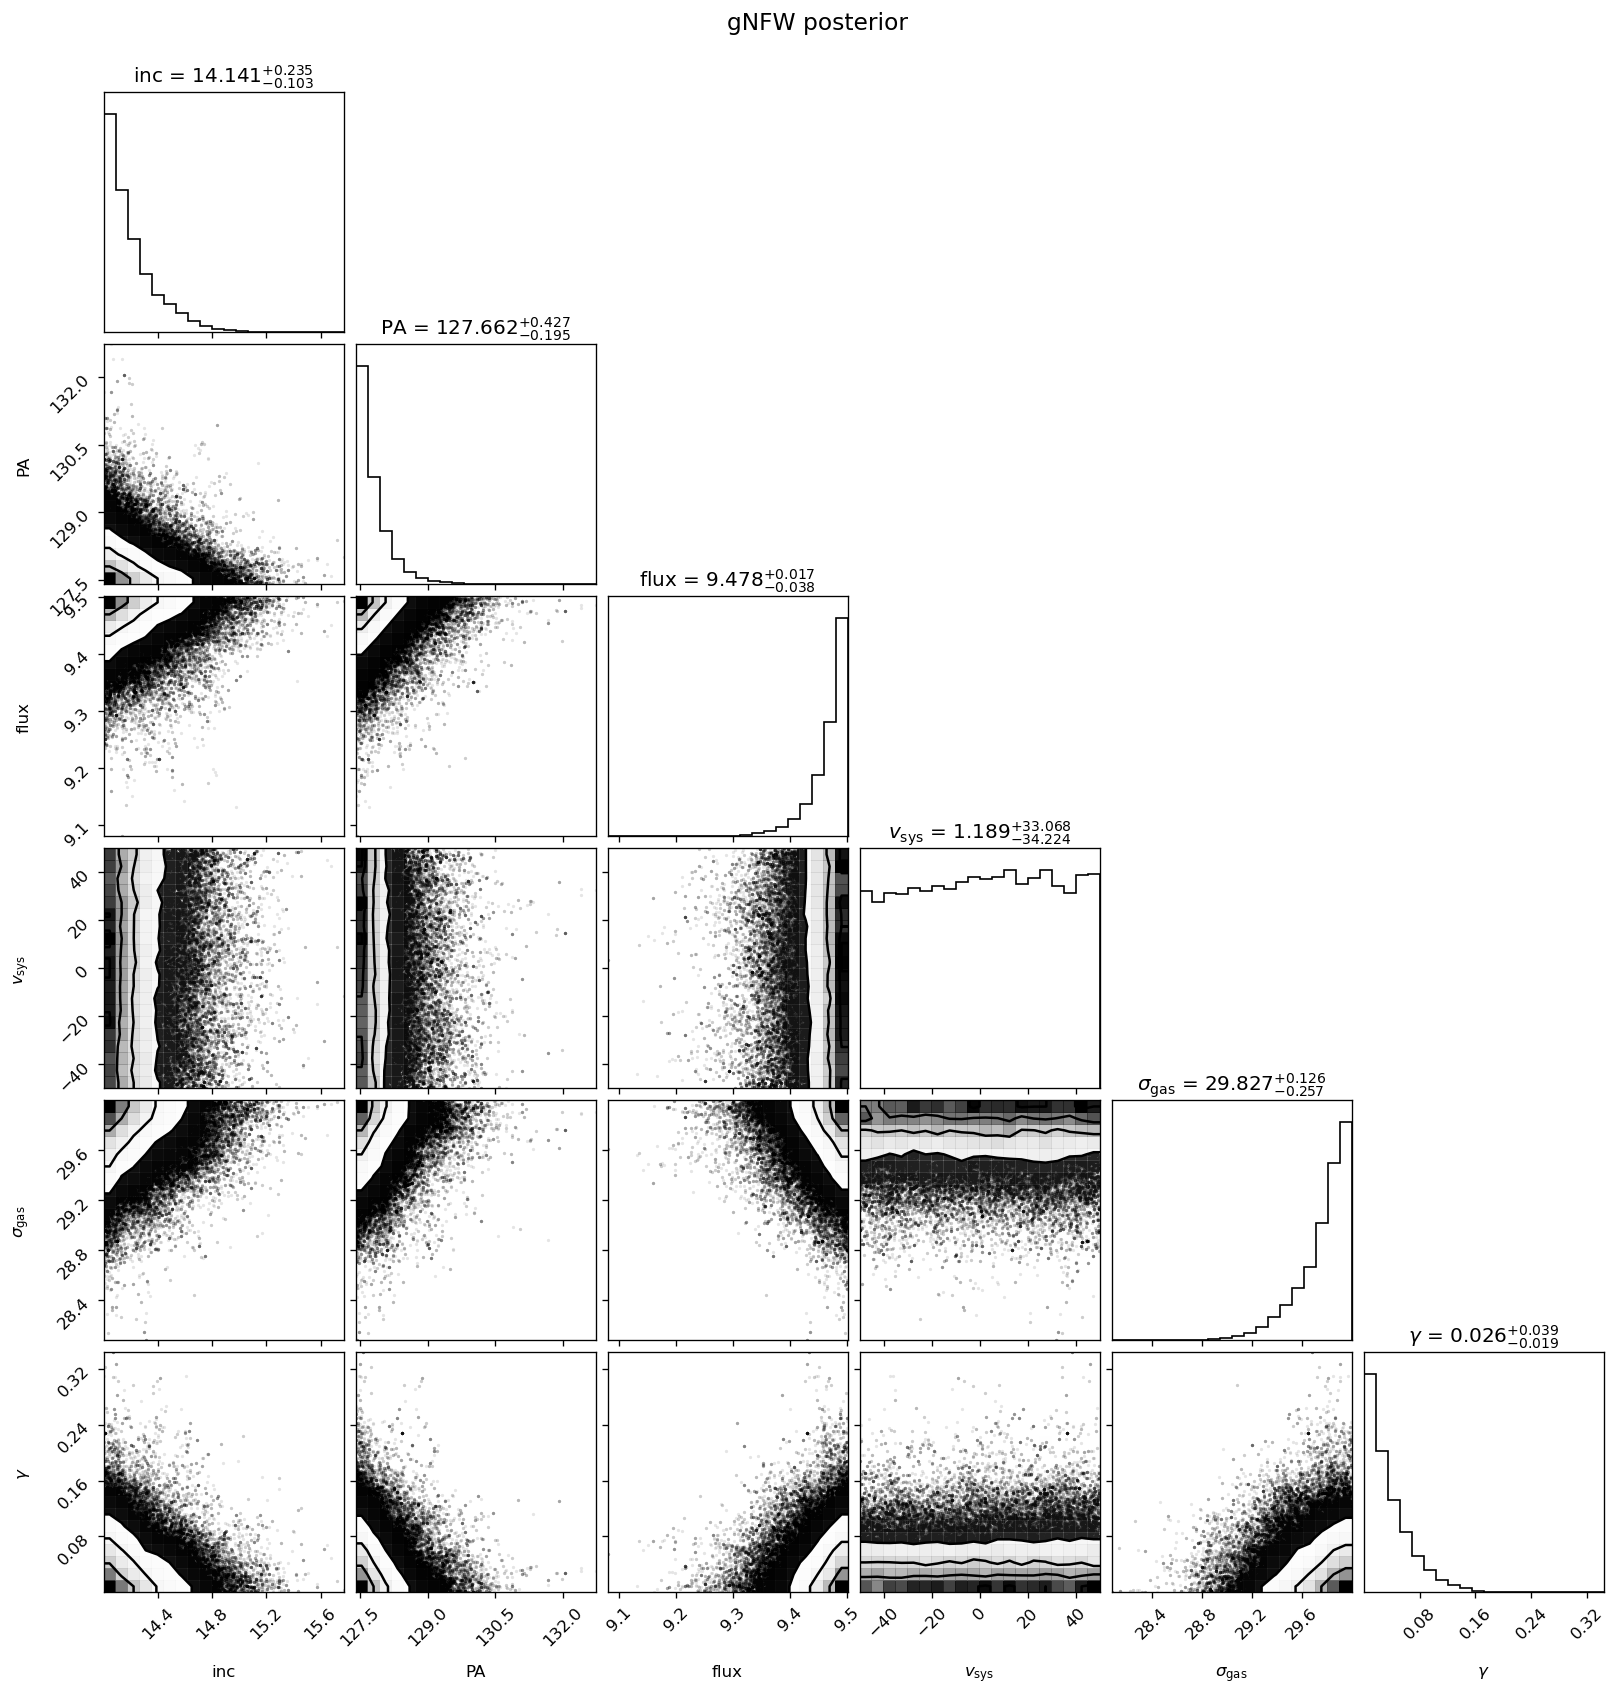

In [5]:
samples = res["chains"].reshape(-1, n_params)
labels = ["inc", "PA", "flux", r"$v_{\rm sys}$", r"$\sigma_{\rm gas}$", r"$\gamma$"]

fig = corner.corner(
    samples, labels=labels, show_titles=True,
    title_fmt=".3f",
)
fig.suptitle("gNFW posterior", y=1.02, fontsize=14)
plt.show()

## Gamma posterior

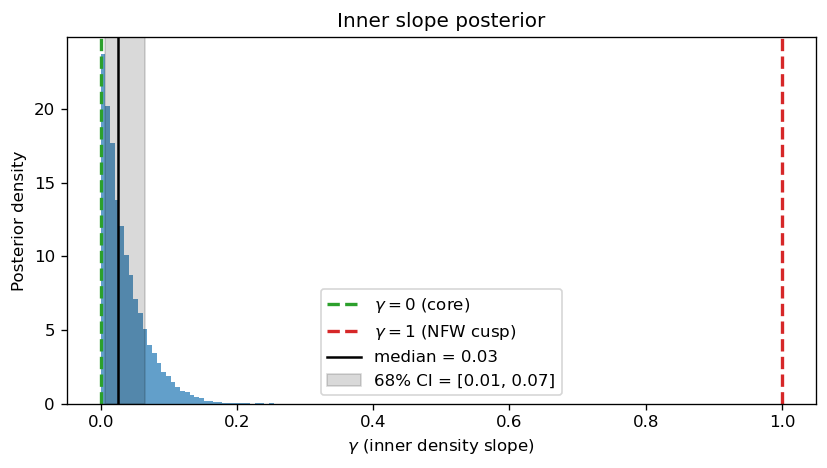

In [6]:
gamma_idx = param_names.index("gamma")
gamma_samples = samples[:, gamma_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gamma_samples, bins=50, density=True, color="C0", alpha=0.7)
ax.axvline(0.0, color="C2", ls="--", lw=2, label=r"$\gamma=0$ (core)")
ax.axvline(1.0, color="C3", ls="--", lw=2, label=r"$\gamma=1$ (NFW cusp)")
med = np.median(gamma_samples)
lo, hi = np.percentile(gamma_samples, [16, 84])
ax.axvline(med, color="k", ls="-", lw=1.5,
           label=f"median = {med:.2f}")
ax.axvspan(lo, hi, alpha=0.15, color="k",
           label=f"68% CI = [{lo:.2f}, {hi:.2f}]")
ax.set_xlabel(r"$\gamma$ (inner density slope)")
ax.set_ylabel("Posterior density")
ax.legend()
ax.set_title("Inner slope posterior")
plt.tight_layout()
plt.show()

## Best-fit model cube (spectral-cube + pymakeplots)

/arc/home/thbrown/.conda/envs/uvkin/lib/python3.12/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


TypeError: Projection.quicklook() got an unexpected keyword argument 'ax'

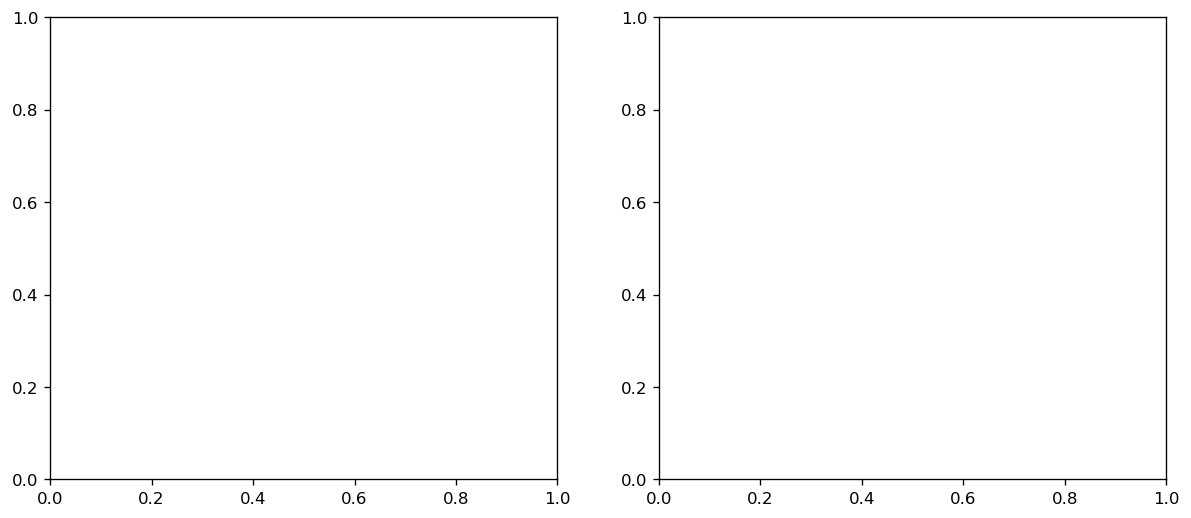

In [7]:
import astropy.units as u

fits_path = RESULTS_DIR / "bestfit_cube.fits"
if not fits_path.is_file():
    raise FileNotFoundError(
        f"Missing {fits_path}; run run_kgas_full.py to write bestfit_cube.fits."
    )

cube_sc = SpectralCube.read(fits_path)
cube_sc.allow_huge_operations = True

mom0 = cube_sc.moment(order=0)
mom1 = cube_sc.moment(order=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mom0.quicklook(ax=axes[0])
axes[0].set_title("Moment 0")
mom1.quicklook(ax=axes[1])
axes[1].set_title("Moment 1 (intensity-weighted velocity)")
plt.tight_layout()
plt.show()

_, ny, nx = cube_sc.shape
cy, cx = ny // 2, nx // 2
spec = cube_sc[:, cy, cx]
v_axis = spec.spectral_axis.to(u.km / u.s)
plt.figure(figsize=(8, 4))
_spec_y = np.asarray(spec.value).ravel()
if np.iscomplexobj(_spec_y):
    _spec_y = np.real(_spec_y)
plt.plot(v_axis.value, _spec_y)
plt.xlabel(f"Velocity ({v_axis.unit})")
ylabel = "Intensity" if spec.unit is None else str(spec.unit)
plt.ylabel(ylabel)
plt.title(f"Spectrum at pixel (y={cy}, x={cx})")
plt.tight_layout()
plt.show()

p = pmp(cube=str(fits_path))
p.vsys = VSYS
p.posang = best_params["pa"]
gamma_map = best_params["gamma"]
p.galname = f"gNFW ($\\gamma$={gamma_map:.2f})"
p.make_all()

## Parameter summary table

In [ ]:
print(f"{'Param':<12} {'MAP':>12} {'Median':>12} {'16-84%':>20}")
print("-" * 60)
for i, name in enumerate(param_names):
    m = best_params[name]
    q = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{name:<12} {m:>12.3f} {q[1]:>12.3f} [{q[0]:.3f}, {q[2]:.3f}]")